In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# data = pd.read_table('b1.txt', names=['x','d1','d2','d3','d4','d5','d6'])
# data['t'] = data.index * 1e-5
# data[['t','x']].to_csv('data.txt', index=None)

In [17]:
data = pd.read_table('x1_20s.txt', sep=",").rename(columns={'x1':'x'})
data.index.name = 't'
data_downsampled = data[::100]
data_downsampled.to_csv('x1_downsampled.csv', index=None)

In [18]:
data_downsampled

,x
t,
0,-0.053535
100,-0.438289
200,-0.061675
300,0.613966
400,-0.009585
...,...
999500,0.125422
999600,0.044107
999700,-0.092617


<Axes: xlabel='t'>

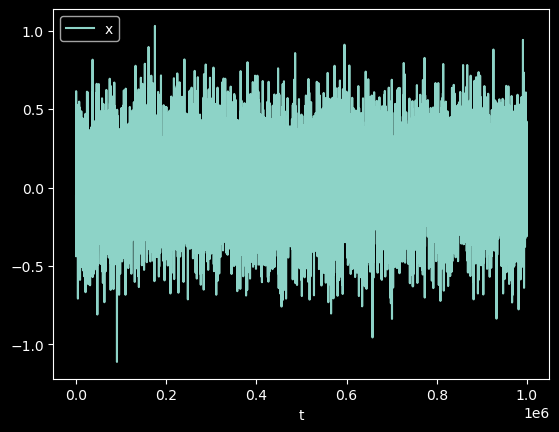

In [19]:
data_downsampled.plot()

<ErrorbarContainer object of 3 artists>

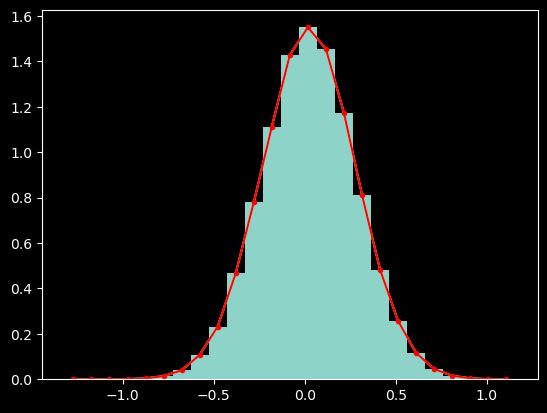

In [20]:
heights, bins, _ = plt.hist(data['x'], bins=25, density=True)

dx = bins[1]-bins[0]
N = len(data)

raw_counts, raw_bins = np.histogram(data['x'], bins=25, density=False)

heights_err = np.sqrt(raw_counts)/N

bins = bins[:-1]+dx/2
plt.plot(bins, heights)
plt.errorbar(bins, heights, yerr=heights_err, marker='.', color='r')

In [30]:
dx

0.09905543999999988

[14.9560588   0.02204114]
[0.05055646 0.00062048]


<ErrorbarContainer object of 3 artists>

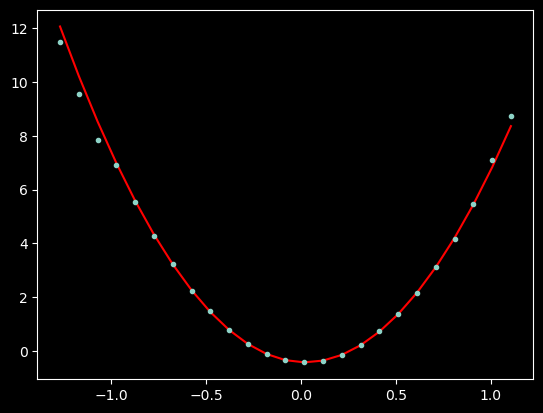

In [21]:
U_err = 2*heights_err/heights
popt, pcov = scipy.optimize.curve_fit(lambda x, k, x_0: 0.5*k*(x-x_0)**2-0.5*np.log(k/(2*np.pi)), xdata=bins, ydata=-np.log(heights), p0=[8, 0.5], sigma=U_err)
plt.plot(bins, 0.5*popt[0]*(bins-popt[1])**2-0.5*np.log(popt[0]/(2*np.pi)), 'r')
print(popt)
print(np.sqrt(np.diag(pcov)))

plt.errorbar(bins, -np.log(heights), yerr=U_err, lw=0, marker='.')

In [22]:
1/np.std(data['x'])**2

15.155450189342096

In [34]:
df = pd.DataFrame(np.array([bins, heights, np.where(heights != 0, -np.log(heights), np.nan), U_err])).T.rename(columns={0: 'x', 1: 'p', 2: 'E', 3:'dE'})
df.to_csv('gaussian_data.csv', index=None)

In [24]:
len(data['x'])

1000000

array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 2.4998e+04, 2.4999e+04,
       2.5000e+04])

In [72]:
len(S)

25001

[0.9722302  3.38290397]


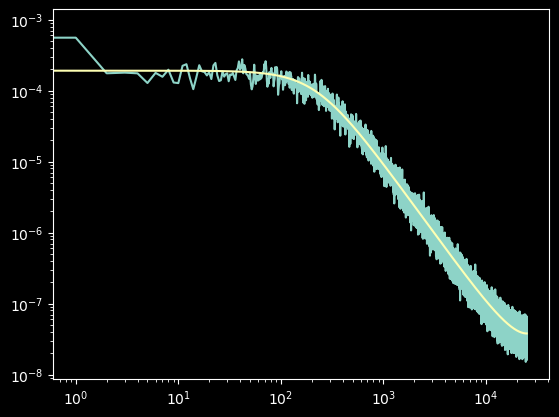

In [86]:
S_f, S = scipy.signal.welch(data['x'], fs=1/2e-5, noverlap=0, nperseg=round((len(data['x'])-1)/20/2)*2, detrend=False)
plt.loglog(S_f, S)


def aliased_lorentzian(n, c, D):
    dt=0.5e-5
    N=len(S)
    return (0.5/np.pi)*((1-c**2)*D*dt)/(1+c**2-2*c*np.cos(np.pi*n/N))

params, pcov = scipy.optimize.curve_fit(aliased_lorentzian, xdata=S_f[200:24000], ydata=S[200:24000], p0=[np.exp(-2*np.pi*200/5e4), 50])
print(params)
plt.loglog(S_f, aliased_lorentzian(S_f, *params))
PSD_df = pd.DataFrame(np.array([S, aliased_lorentzian(S_f, *params)]).T, index=S_f, columns=['S', 'S_pred'])
PSD_df.index.name = 'f'
PSD_df.to_csv("psd.csv")

In [55]:
params

array([0.94540453, 3.3830127 ])

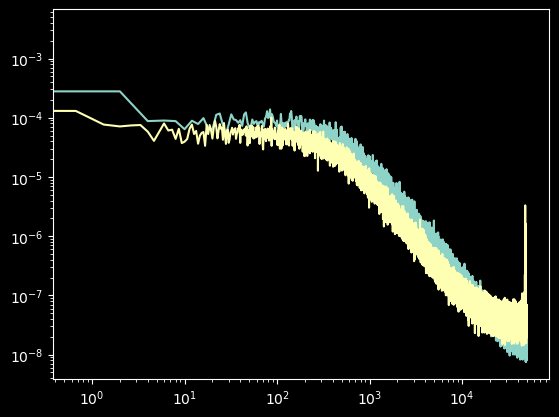

In [26]:
PS_f, PS = np.genfromtxt('PS_x1.txt', skip_header=1, delimiter=",").T

plt.loglog(S_f, S)
plt.loglog(PS_f, PS)